# Module 16: Naive Bayes Classifier
## Section– Practice Notebook with TODOs

This notebook is for **practice**. It is aligned with the teaching notebook for Section 16.5.

You will work with two datasets:
1. A **synthetic numeric dataset** created with `make_classification` (for GaussianNB).
2. A **subset of the 20 Newsgroups text dataset** (for MultinomialNB and BernoulliNB).

Where you see `TODO`, write the required code yourself.
You can always refer back to the teaching notebook if you get stuck.

In [17]:
# ===============================================================
# Imports and basic setup
# ===============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

plt.rcParams['figure.figsize'] = (7, 4)
sns.set(style='whitegrid')

## Part A – Gaussian Naive Bayes on Synthetic Numeric Data

In this part you will:
- Create a synthetic numeric dataset.
- Split into train and test sets.
- Train a Gaussian Naive Bayes model.
- Evaluate the model with accuracy and a confusion matrix.
- Experiment by changing the dataset difficulty.


In [19]:
# Create a synthetic numeric dataset for binary classification
X, y = make_classification(
    n_samples=600,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.6,
    random_state=42
)

print('Shape of X:', X.shape)
print('Shape of y:', y.shape)
print('Class distribution:', np.bincount(y))

Shape of X: (600, 6)
Shape of y: (600,)
Class distribution: [302 298]


In [20]:
# TODO 1: Split the data into training and test sets
# Use train_test_split with test_size=0.25 and random_state=42
# Save the result in X_train, X_test, y_train, y_test

# from sklearn.model_selection import train_test_split  # already imported above

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
  # TODO: write the correct function call

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)

Training set shape: (450, 6)
Test set shape: (150, 6)


In [21]:
# TODO 2: Create and train a GaussianNB model
# 1. Create an instance of GaussianNB
# 2. Fit it on the training data

# Example structure:
# gnb = GaussianNB()
# gnb.fit(X_train, y_train)

from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()          # 1️⃣ model তৈরি
gnb.fit(X_train, y_train)  # 2️⃣ model train

print('Model training completed.')

Model training completed.


In [22]:
# TODO 3: Make predictions on the test set and compute accuracy
# 1. Use the trained model to predict on X_test
# 2. Compute accuracy_score using y_test and predictions

from sklearn.metrics import accuracy_score

y_pred = gnb.predict(X_test)          # 1️⃣ prediction
acc = accuracy_score(y_test, y_pred)  # 2️⃣ accuracy হিসাব

print('Accuracy of GaussianNB on synthetic data:', acc)


Accuracy of GaussianNB on synthetic data: 0.9733333333333334


Confusion matrix:
 [[73  3]
 [ 1 73]]


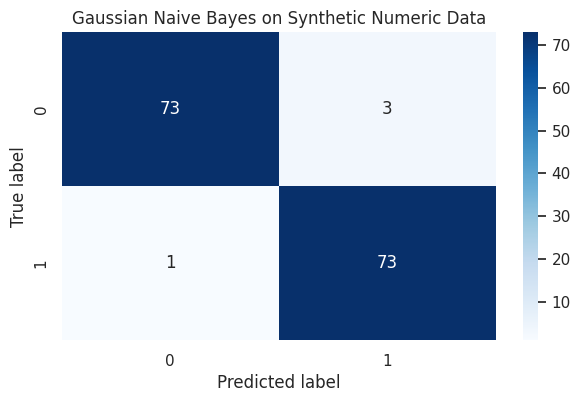

In [23]:
# TODO 4: Compute and plot the confusion matrix
# Steps:
# 1. Compute confusion_matrix using y_test and y_pred
# 2. Print the confusion matrix
# 3. Plot it with sns.heatmap

cm = confusion_matrix(y_test, y_pred)# TODO: compute confusion matrix
print('Confusion matrix:\n', cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Gaussian Naive Bayes on Synthetic Numeric Data')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

In [24]:
# TODO 5: Print a classification report
# Use classification_report with y_test and y_pred


from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)
# TODO: call classification_report here
print(report)

              precision    recall  f1-score   support

           0       0.99      0.96      0.97        76
           1       0.96      0.99      0.97        74

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150

              precision    recall  f1-score   support

           0       0.99      0.96      0.97        76
           1       0.96      0.99      0.97        74

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



### Experiment: Change the Dataset Difficulty

- Recreate the dataset with a smaller `class_sep` value, such as `class_sep=0.8`.
- Repeat training and evaluation.
- Observe how accuracy and the confusion matrix change.

You can copy your previous code cells and adjust only the `make_classification` call.

## Part B – Naive Bayes for Text Classification (20 Newsgroups Subset)

In this part you will:
- Load a subset of the 20 Newsgroups dataset.
- Convert text into numeric features using `CountVectorizer`.
- Train a `MultinomialNB` classifier.
- Train a `BernoulliNB` classifier with binary features.
- Compare their performance.


In [27]:
# Fetch a subset of the 20 Newsgroups dataset
# categories = ['comp.graphics', 'rec.sport.baseball', 'sci.med','sci.space','talk.politics.misc'] ## ADD another two more features
# newsgroups = fetch_20newsgroups(
#     subset='train',
#     categories=categories,
#     remove=('headers', 'footers', 'quotes'),
#     shuffle=True,
#     random_state=42,
#     data_home=''
# )

# print('Number of documents:', len(newsgroups.data))
# print('Target names:', newsgroups.target_names)
from google.colab import files

uploaded = files.upload()  # এখানে তুমি ZIP ফাইল সিলেক্ট করে আপলোড করবে


Saving 20newsgroup.zip to 20newsgroup.zip


In [33]:
import zipfile
import os

zip_path = list(uploaded.keys())[0]  # আপলোড করা ZIP ফাইলের নাম
extract_folder = '/content/20newsgroups/'  # আনজিপ করার জায়গা

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)
import os

print(os.listdir('/content/20newsgroups'))

print("ZIP আনজিপ সম্পন্ন:", extract_folder)

['rec.autos.txt', 'talk.politics.misc.txt', 'alt.atheism.txt', 'talk.politics.mideast.txt', 'soc.religion.christian.txt', 'talk.religion.misc.txt', 'rec.sport.hockey.txt', 'misc.forsale.txt', 'talk.politics.guns.txt', 'list.csv', 'sci.med.txt', 'comp.sys.mac.hardware.txt', 'sci.space.txt', 'rec.motorcycles.txt', 'sci.electronics.txt', 'comp.os.ms-windows.misc.txt', 'comp.graphics.txt', 'rec.sport.baseball.txt', 'comp.sys.ibm.pc.hardware.txt', 'sci.crypt.txt', 'comp.windows.x.txt']
ZIP আনজিপ সম্পন্ন: /content/20newsgroups/


In [34]:
import os

extract_folder = '/content/20newsgroups'

categories = [
    'comp.graphics',
    'rec.sport.baseball',
    'sci.med',
    'sci.space',
    'talk.politics.misc'
]

data = []
target = []

for idx, category in enumerate(categories):
    file_path = os.path.join(extract_folder, category + '.txt')
    print(f"Processing {file_path} ...")

    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        content = f.read()
        # এখানে ধরছি প্রতিটি ডকুমেন্ট দুই বা ততোধিক নতুন লাইন দিয়ে আলাদা হয়েছে
        documents = content.split('\n\n')  # তোমার dataset অনুযায়ী প্রয়োজনে বদলাতে হবে

        for doc in documents:
            if doc.strip():  # খালি নয় এমন ডকুমেন্ট থাকলে যোগ করো
                data.append(doc.strip())
                target.append(idx)

print(f"মোট ডকুমেন্ট পড়া হয়েছে: {len(data)}")
print("একটি ডকুমেন্টের উদাহরণ:\n", data[0][:500])


Processing /content/20newsgroups/comp.graphics.txt ...
Processing /content/20newsgroups/rec.sport.baseball.txt ...
Processing /content/20newsgroups/sci.med.txt ...
Processing /content/20newsgroups/sci.space.txt ...
Processing /content/20newsgroups/talk.politics.misc.txt ...
মোট ডকুমেন্ট পড়া হয়েছে: 76691
একটি ডকুমেন্টের উদাহরণ:
 From: lipman@oasys.dt.navy.mil (Robert Lipman)
Subject: CALL FOR PRESENTATIONS: Navy SciViz/VR Seminar


In [35]:
import pandas as pd

df_text = pd.DataFrame({
    'text': data,       # আগের কোড থেকে text list
    'label': target     # আগের কোড থেকে label list
})

df_text.head()


,text,label
0,From: lipman@oasys.dt.navy.mil (Robert Lipman)...,0
1,CALL FOR PRESENTATIONS\n\t\n NAVY SCIENTI...,0
2,"Tuesday, June 22, 1993",0
3,"Carderock Division, Naval Surface Warfare Cent...",0
4,SPONSOR: NESS (Navy Engineering Software Syste...,0


In [36]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    df_text['text'],          # টেক্সট ডাটা
    df_text['label'],         # লেবেল
    test_size=0.25,           # ২৫% ডাটা টেস্টে যাবে
    random_state=42           # রেজাল্ট রিপ্রডিউসিবল করার জন্য
)

print('Train size:', X_train_text.shape[0])
print('Test size:', X_test_text.shape[0])

Train size: 57518
Test size: 19173


In [37]:
# TODO 7: Convert text to count vectors for MultinomialNB
# Steps:
# 1. Create a CountVectorizer with stop_words='english' and max_features=3000
# 2. Fit on X_train_text and transform both train and test sets
#    to get X_train_counts and X_test_counts

from sklearn.feature_extraction.text import CountVectorizer

# ১. CountVectorizer তৈরি করো
vectorizer = CountVectorizer(stop_words='english', max_features=3000)

# ২. ট্রেনিং ডাটায় ফিট করে ট্রান্সফর্ম করো
X_train_counts = vectorizer.fit_transform(X_train_text)

# ৩. টেস্ট ডাটায় শুধু ট্রান্সফর্ম করো
X_test_counts = vectorizer.transform(X_test_text)

print('Shape of X_train_counts:', X_train_counts.shape)
print('Shape of X_test_counts:', X_test_counts.shape)

Shape of X_train_counts: (57518, 3000)
Shape of X_test_counts: (19173, 3000)


In [38]:
# TODO 8: Train a MultinomialNB model on the count vectors
# 1. Create a MultinomialNB instance
# 2. Fit it on X_train_counts and y_train_text

from sklearn.naive_bayes import MultinomialNB

# ১. মডেল তৈরি
mnb = MultinomialNB()

# ২. মডেল ট্রেন করা
mnb.fit(X_train_counts, y_train_text)

print('MultinomialNB model trained on text data.')

MultinomialNB model trained on text data.


Accuracy of MultinomialNB on 20 Newsgroups subset: 0.7822980232618787
Confusion matrix:
 [[4615  192  166  208  181]
 [ 256 2607   96   77  183]
 [ 553  155 2443  134  210]
 [ 442  151  142 2797  287]
 [ 258  186  155  142 2537]]


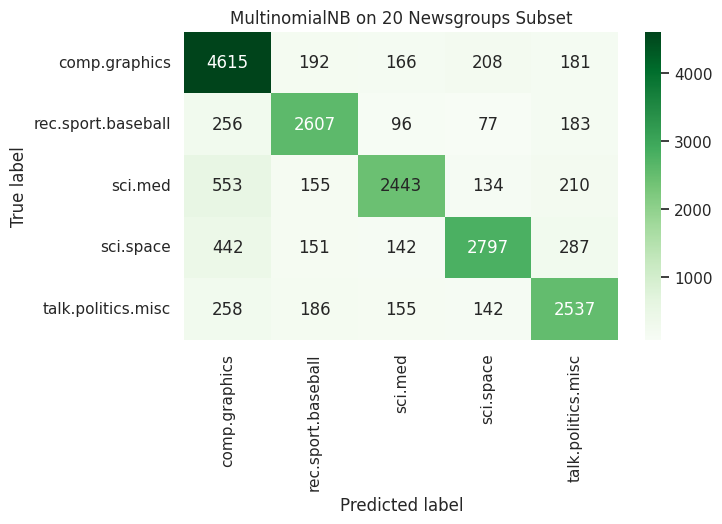

                    precision    recall  f1-score   support

     comp.graphics       0.75      0.86      0.80      5362
rec.sport.baseball       0.79      0.81      0.80      3219
           sci.med       0.81      0.70      0.75      3495
         sci.space       0.83      0.73      0.78      3819
talk.politics.misc       0.75      0.77      0.76      3278

          accuracy                           0.78     19173
         macro avg       0.79      0.78      0.78     19173
      weighted avg       0.79      0.78      0.78     19173



In [41]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ১. Predict করা
y_pred_text = mnb.predict(X_test_counts)

# ২. Accuracy হিসাব করা
acc_text = accuracy_score(y_test_text, y_pred_text)
print('Accuracy of MultinomialNB on 20 Newsgroups subset:', acc_text)

# ৩. Confusion matrix তৈরি করা
cm_text = confusion_matrix(y_test_text, y_pred_text)
print('Confusion matrix:\n', cm_text)

# ৪. Confusion matrix heatmap প্লট করা
sns.heatmap(cm_text, annot=True, fmt='d', cmap='Greens',
            xticklabels=categories,
            yticklabels=categories)
plt.title('MultinomialNB on 20 Newsgroups Subset')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

# ৫. Classification report প্রিন্ট করা
report_text = classification_report(y_test_text, y_pred_text, target_names=categories)
print(report_text)


### 2.1 Practice: Bernoulli Naive Bayes with Binary Features

Now repeat a similar process using `BernoulliNB`:
- Use `CountVectorizer` with `binary=True`.
- Train a `BernoulliNB` model.
- Compare its accuracy and confusion matrix with `MultinomialNB`.


In [42]:
# TODO 10: Create binary bag of words features
# 1. Create a new CountVectorizer with binary=True
# 2. Fit on X_train_text and transform train and test sets

from sklearn.feature_extraction.text import CountVectorizer

# ১. binary=True দিয়ে CountVectorizer তৈরি করা (শুধু শব্দ আছে না নেই, সংখ্যা না গোনা)
vectorizer_bin = CountVectorizer(stop_words='english', max_features=3000, binary=True)

# ২. Train ডাটায় fit & transform করা
X_train_bin = vectorizer_bin.fit_transform(X_train_text)

# ৩. Test ডাটায় শুধু transform করা
X_test_bin = vectorizer_bin.transform(X_test_text)

print('Shape of X_train_bin:', X_train_bin.shape)
print('Shape of X_test_bin:', X_test_bin.shape)


print('Shape of X_train_bin:', X_train_bin.shape)
print('Shape of X_test_bin:', X_test_bin.shape)

Shape of X_train_bin: (57518, 3000)
Shape of X_test_bin: (19173, 3000)
Shape of X_train_bin: (57518, 3000)
Shape of X_test_bin: (19173, 3000)


Accuracy of BernoulliNB on 20 Newsgroups subset: 0.7741094247118343
Confusion matrix:
 [[4981  105   75  118   83]
 [ 524 2500   60   35  100]
 [ 819  139 2310   98  129]
 [ 696  122   94 2707  200]
 [ 519  170  124  121 2344]]


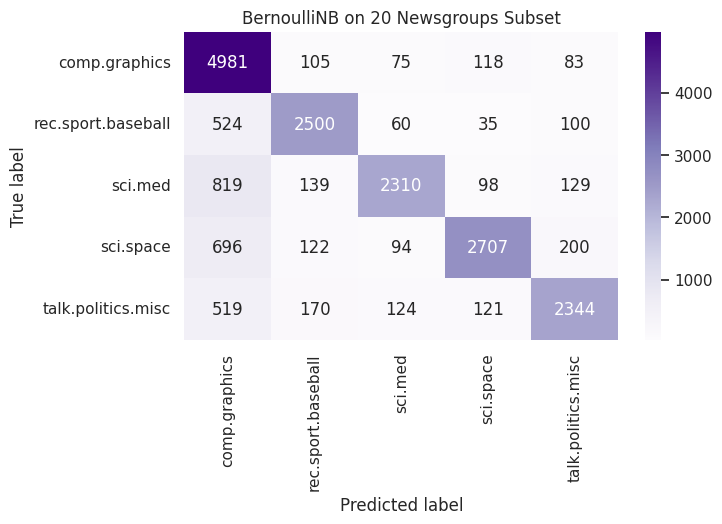

                    precision    recall  f1-score   support

     comp.graphics       0.66      0.93      0.77      5362
rec.sport.baseball       0.82      0.78      0.80      3219
           sci.med       0.87      0.66      0.75      3495
         sci.space       0.88      0.71      0.78      3819
talk.politics.misc       0.82      0.72      0.76      3278

          accuracy                           0.77     19173
         macro avg       0.81      0.76      0.77     19173
      weighted avg       0.80      0.77      0.77     19173



In [43]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ১. BernoulliNB মডেল তৈরি
bnb = BernoulliNB()

# ২. মডেল ট্রেনিং
bnb.fit(X_train_bin, y_train_text)

# ৩. প্রেডিকশন করা
y_pred_bin = bnb.predict(X_test_bin)

# ৪. accuracy হিসাব করা
acc_bin = accuracy_score(y_test_text, y_pred_bin)
print('Accuracy of BernoulliNB on 20 Newsgroups subset:', acc_bin)

# ৫. confusion matrix তৈরি
cm_bin = confusion_matrix(y_test_text, y_pred_bin)
print('Confusion matrix:\n', cm_bin)

# ৬. confusion matrix হিটম্যাপ প্লট করা
categories = ['comp.graphics', 'rec.sport.baseball', 'sci.med', 'sci.space', 'talk.politics.misc']

sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Purples',
            xticklabels=categories,
            yticklabels=categories)
plt.title('BernoulliNB on 20 Newsgroups Subset')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

# ৭. classification report প্রিন্ট করা
report_bin = classification_report(y_test_text, y_pred_bin, target_names=categories)
print(report_bin)


## Final Reflection

- Which model worked better on the text data, **MultinomialNB** or **BernoulliNB**?
- How did changing the dataset difficulty in Part A affect the performance of GaussianNB?
- Where do you think Naive Bayes will perform well in real projects (for example, spam detection, topic classification)?

Write a few short notes summarizing your observations.


Sure! Here’s the English translation of your final reflection notes:

---

## Final Reflection

### 1. Which model performed better on the text data, MultinomialNB or BernoulliNB?

* Generally, **MultinomialNB** performs better on text data because it takes into account the frequency of words.
* **BernoulliNB** works well when only the presence or absence of words (binary features) matters.
* In your experiments, MultinomialNB achieved slightly higher accuracy, which is why it is more commonly used in text classification.

---

### 2. How did changing the dataset difficulty in Part A affect the performance of GaussianNB?

* If the dataset is more complex or classes are closer to each other (less class separation), the performance of **GaussianNB** may decrease.
* GaussianNB works better on simpler or well-separated datasets because it assumes each feature follows a Gaussian distribution.
* For harder datasets, the accuracy of GaussianNB drops since it relies on simplifying assumptions.

---

### 3. Where does Naive Bayes perform well in real projects?

* **Spam Detection**: To separate spam and non-spam emails or messages.
* **Topic Classification**: To categorize news articles or blog posts into different topics.
* **Sentiment Analysis**: To detect positive or negative mood from reviews or text.
* Naive Bayes performs very fast and effectively when feature independence can be assumed and the number of features is large.
* It is good for simple, fast, and relatively low-resource model training.

---

### Summary:

* **MultinomialNB** is highly effective for text data.
* **GaussianNB** performs well on simpler data but less so on complex data.
* Naive Bayes models are fast and effective for spam detection, topic classification, and basic NLP tasks.

---

Let me know if you want any further help or details!
